# Week 5: HealthConnect Solution Development
## Data Preparation, Feature Engineering & Baseline Model Development

## Part 1: Review of My Week 4 Foundation

**1. The problem I defined:**
HealthConnect Clinic loses clinic capacity when patients miss scheduled appointments. I defined this as a **binary classification problem**: predicting whether a scheduled appointment will end in a **No-Show**, so the clinic can intervene early with reminders, rescheduling support, or smarter slot allocation.

**2. My Week 4 proposed approach:**
- Use `appointment_outcome` as the target, binarised as `No-Show = 1` and `Attended = 0`.
- **Exclude `Cancelled` appointments** from modelling, because a cancellation is an active, communicated change that frees the slot, while a No-Show is the unpredictable event I want to predict.
- Candidate features: patient demographics (`age`, `gender`), appointment characteristics (`appointment_type`, `appointment_day`, `appointment_time`, `booking_lead_days`, `distance_to_clinic_km`), patient history (`previous_appointments`, `previous_no_shows`) and reminder information (`reminder_sent`, `reminder_channel`).
- Begin with **Logistic Regression** as an interpretable baseline, with class weights to handle imbalance.

**3. HealthConnect resources relevant to my work:**
- `HealthConnect_Appointment_Data.csv` – the modelling dataset.
- `HealthConnect_Data_Dictionary` – variable definitions and data-quality notes (e.g., limited missing values in `distance_to_clinic_km` and `waiting_time_minutes`).

**4. Key assumptions and limitations identified in Week 4:**
- `waiting_time_minutes` is a **leakage risk**: the actual waiting time is only known after a patient attends, so it must not be used as a predictor.
- Missing values in `distance_to_clinic_km` and `waiting_time_minutes` need careful imputation.
- The target is imbalanced (No-Shows are the minority), so accuracy alone would be misleading.
- The data is synthetic, so findings should be treated as directional.

**5. What I proposed to accomplish in Week 5:**
- Prepare and clean the dataset for modelling.
- Engineer meaningful no-show features.
- Define a train/test strategy, train a baseline classifier, and evaluate it with appropriate metrics (Accuracy, Precision, Recall, F1-score, Confusion Matrix, ROC-AUC).
- Document limitations and establish a clear foundation for Week 6.

## Part 2: Data Preparation

Before modelling, I need to prepare the HealthConnect dataset so that it is clean, consistent, and free of leakage. In this section, I address the following:

**My Data Preparation Plan:**
1. **Load and inspect** the raw dataset (shape, data types, missing values, duplicates).
2. **Irrelevant variables:** I will drop `appointment_id` and `patient_id` because they are unique identifiers with no predictive power and would cause the model to memorise records.
3. **Data leakage:** I will drop `waiting_time_minutes`. As I noted in Week 4, the actual waiting time is only recorded *after* a patient attends the appointment. Using it to predict attendance would give the model information it could never have at booking time, producing misleadingly perfect results.
4. **Redundant date columns:** I will drop the raw `booking_date` and `appointment_date` columns because I already have derived temporal features (`appointment_day` and `booking_lead_days`) that capture the same information in a more model-friendly form.
5. **Missing values:** I will impute the limited missing values in `distance_to_clinic_km` using the median, since the distribution is likely skewed.
6. **Duplicates and data types:** I will check for duplicate records and ensure each column has the correct data type.
7. **Save separately:** I will save the cleaned dataset as a new file (`HealthConnect_Cleaned_Data.csv`) so that the original resource is never overwritten.

In [1]:
import pandas as pd
import numpy as np

# Load the original HealthConnect dataset
df = pd.read_csv('HealthConnect_Appointment_Data.csv')

print("--- INITIAL INSPECTION ---")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

--- INITIAL INSPECTION ---
Rows: 5000 | Columns: 18


In [2]:
print("\n--- DATA TYPES ---")
print(df.dtypes)

print("\n--- MISSING VALUES ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values.")


--- DATA TYPES ---
appointment_id            object
patient_id                object
gender                    object
age                        int64
age_group                 object
appointment_type          object
booking_date              object
appointment_date          object
appointment_day           object
appointment_time          object
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent             object
reminder_channel          object
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome       object
dtype: object

--- MISSING VALUES ---
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
dtype: int64


In [3]:
print("\n--- DUPLICATE ROWS ---")
print(f"Exact duplicates: {df.duplicated().sum()}")

print("\n--- FIRST 5 ROWS ---")
display(df.head())


--- DUPLICATE ROWS ---
Exact duplicates: 0

--- FIRST 5 ROWS ---


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


### My Cleaning Decisions & Justifications

| Issue | Column(s) | My Decision | Justification |
|-------|-----------|-------------|---------------|
| Unique identifiers | `appointment_id`, `patient_id` | Drop | No predictive value; risk of memorisation/overfitting. |
| Data leakage | `waiting_time_minutes` | Drop | Only known after a patient attends; unusable at booking time. |
| Redundant dates | `booking_date`, `appointment_date` | Drop | Already captured by `appointment_day` and `booking_lead_days`. |
| Missing values | `distance_to_clinic_km` | Impute with median | Median is robust to skewed distances and outliers. |
| Duplicates | All rows | Remove if found | Prevents the model from overweighting repeated records. |

In [4]:
# Work on a copy so the original is never touched
df_clean = df.copy()

# Remove duplicate rows (if any)
df_clean = df_clean.drop_duplicates()

# Drop irrelevant identifiers
df_clean = df_clean.drop(columns=['appointment_id', 'patient_id'])

# Drop the leakage column
df_clean = df_clean.drop(columns=['waiting_time_minutes'])

# Drop redundant raw date columns
df_clean = df_clean.drop(columns=['booking_date', 'appointment_date'])

# Impute missing values in distance_to_clinic_km with the median
median_distance = df_clean['distance_to_clinic_km'].median()
df_clean['distance_to_clinic_km'] = df_clean['distance_to_clinic_km'].fillna(median_distance)

In [5]:
# Verify the cleaning
print("--- AFTER CLEANING ---")
print(f"Rows: {df_clean.shape[0]} | Columns: {df_clean.shape[1]}")
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")
print(f"Remaining duplicates: {df_clean.duplicated().sum()}")
print("\nRemaining columns:")
print(df_clean.columns.tolist())

--- AFTER CLEANING ---
Rows: 5000 | Columns: 13
Remaining missing values: 1366
Remaining duplicates: 0

Remaining columns:
['gender', 'age', 'age_group', 'appointment_type', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'reminder_channel', 'distance_to_clinic_km', 'appointment_outcome']


In [6]:
# 7. saiving the dateset
df_clean.to_csv('HealthConnect_Cleaned_Data.csv', index=False)
print("\n Cleaned dataset saved as 'HealthConnect_Cleaned_Data.csv'")

display(df_clean.head())


 Cleaned dataset saved as 'HealthConnect_Cleaned_Data.csv'


,gender,age,age_group,appointment_type,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,appointment_outcome
0,Female,39,35-44,Follow-up,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,No-Show
1,Male,31,25-34,Specialist Consultation,Friday,Morning,2,6,0,Yes,SMS,14.3,Attended
2,Female,50,45-54,General Consultation,Wednesday,Morning,38,5,1,Yes,SMS,11.4,No-Show
3,Male,59,55-64,Follow-up,Thursday,Evening,41,3,1,Yes,SMS,7.4,Attended
4,Female,34,25-34,Follow-up,Monday,Afternoon,47,3,1,Yes,Email,5.6,No-Show


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

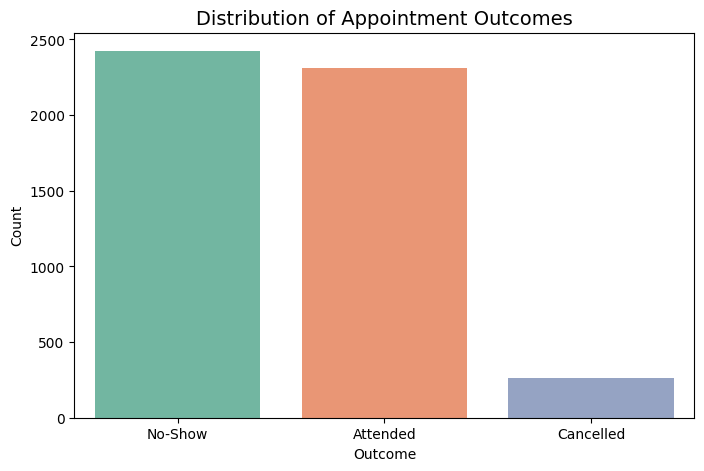

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(x='appointment_outcome', data=df, palette='Set2', hue='appointment_outcome', legend=False)
plt.title('Distribution of Appointment Outcomes', fontsize=14)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

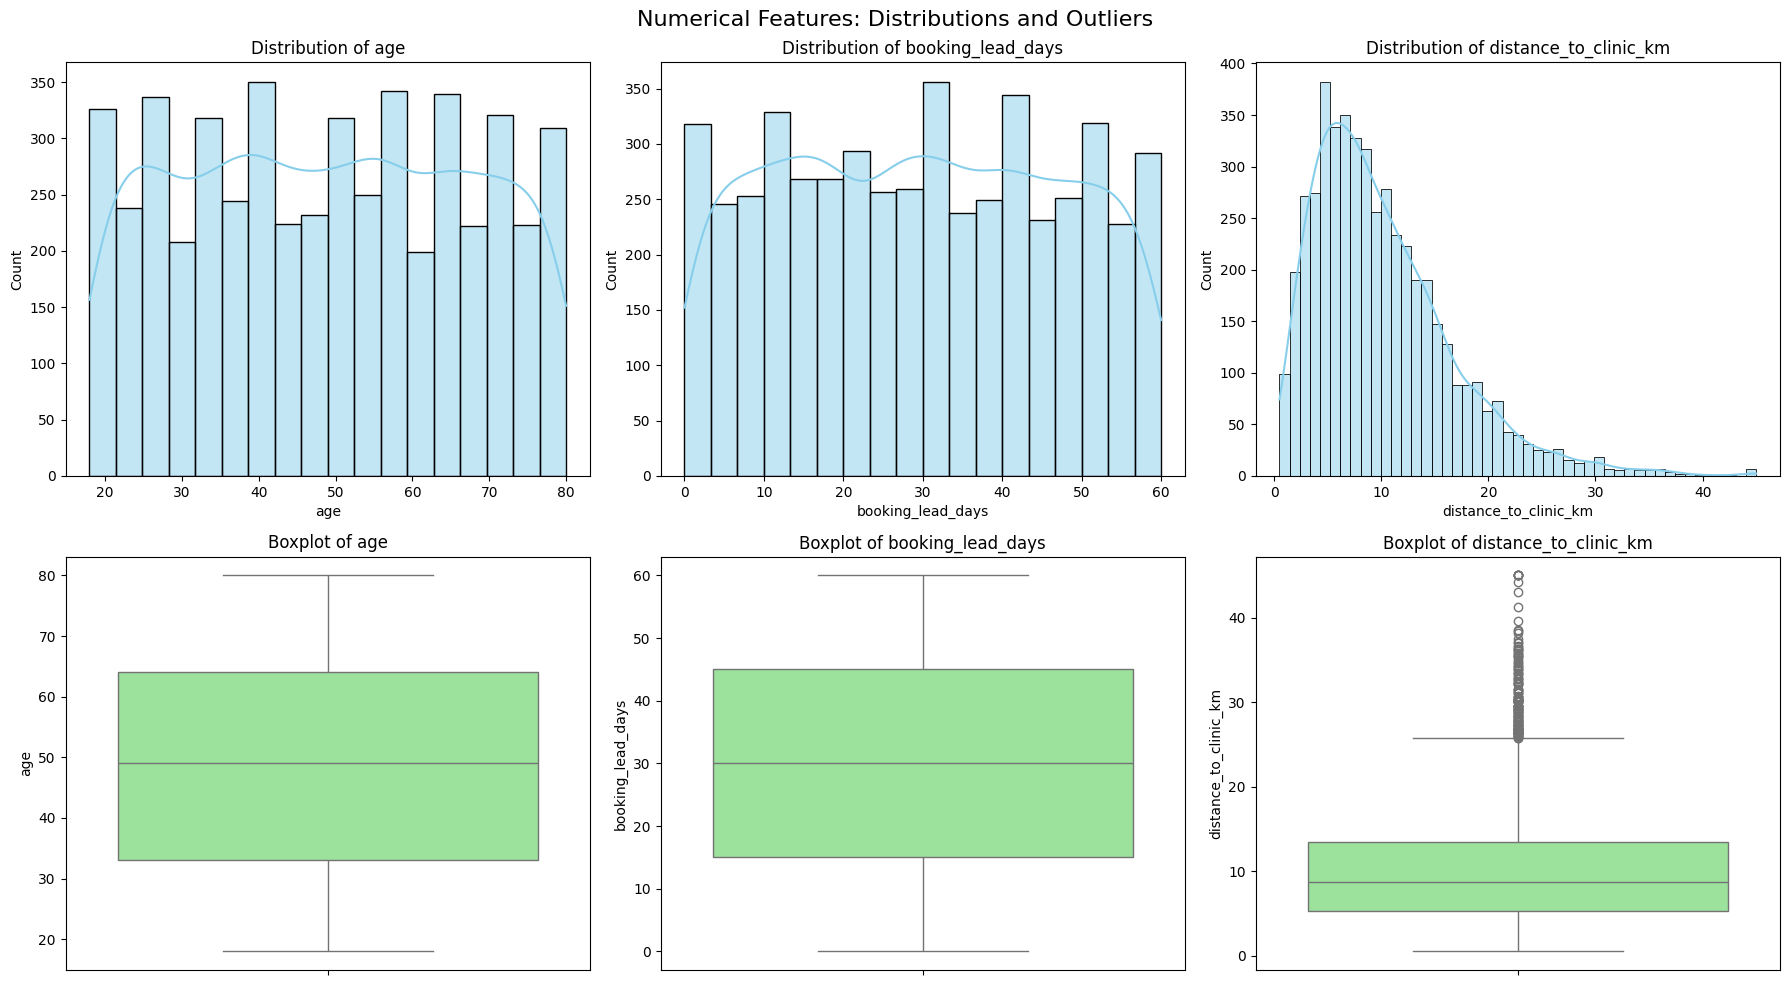

In [9]:
num_cols = ['age', 'booking_lead_days', 'distance_to_clinic_km']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Numerical Features: Distributions and Outliers', fontsize=16)

for i, col in enumerate(num_cols):
    # Histogram
    sns.histplot(df[col].dropna(), ax=axes[0, i], kde=True, color='skyblue')
    axes[0, i].set_title(f'Distribution of {col}')

    # Boxplot
    sns.boxplot(y=df[col], ax=axes[1, i], color='lightgreen')
    axes[1, i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

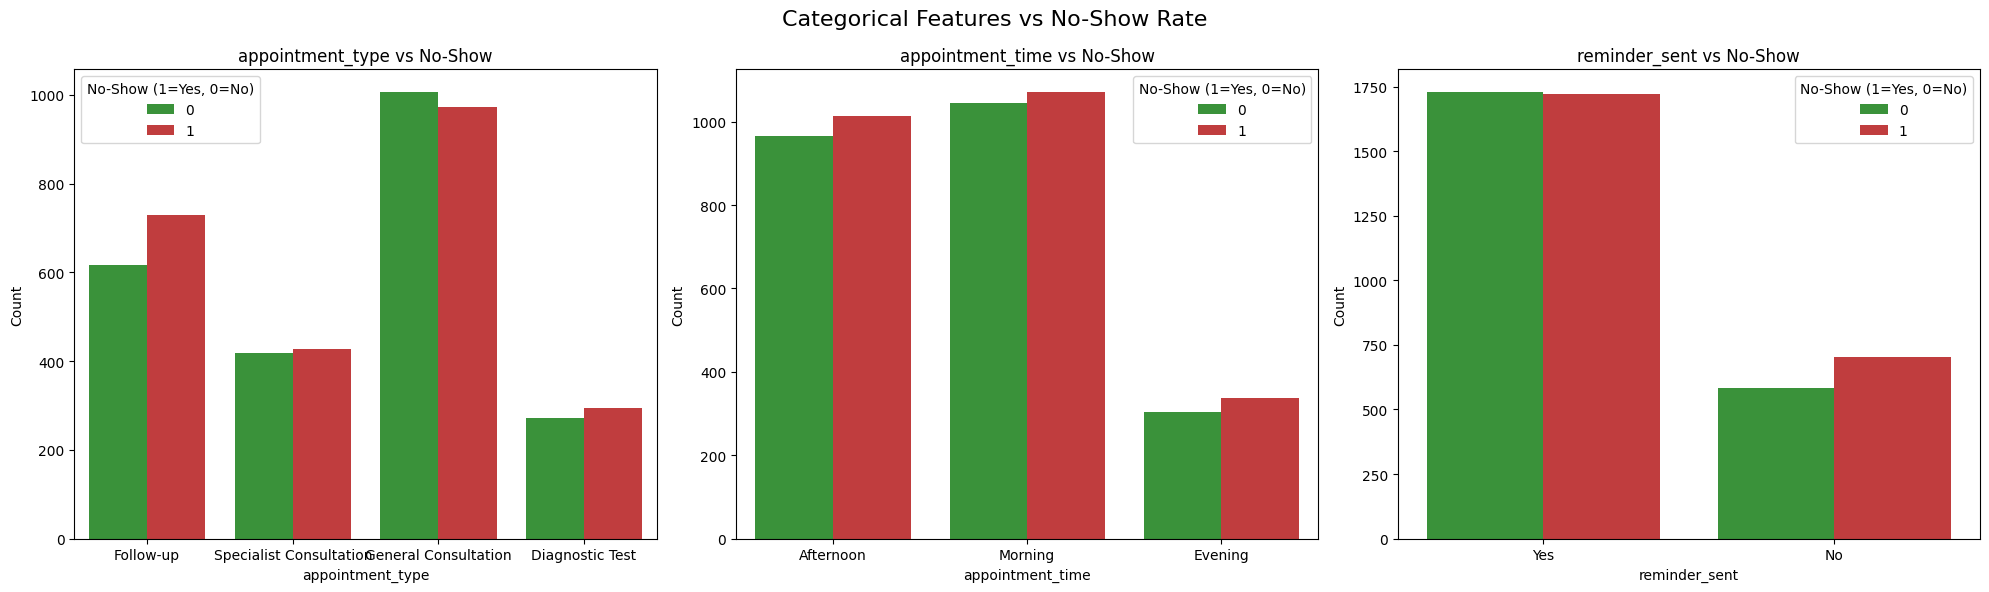

In [10]:
# Filter out Cancelled for binary target analysis
df_binary = df[df['appointment_outcome'] != 'Cancelled'].copy()
df_binary['is_noshow'] = df_binary['appointment_outcome'].apply(lambda x: 1 if x == 'No-Show' else 0)

cat_cols = ['appointment_type', 'appointment_time', 'reminder_sent']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Categorical Features vs No-Show Rate', fontsize=16)

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='is_noshow', data=df_binary, ax=axes[i], palette=['#2ca02c', '#d62728'])
    axes[i].set_title(f'{col} vs No-Show')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='No-Show (1=Yes, 0=No)')

plt.tight_layout()
plt.show()

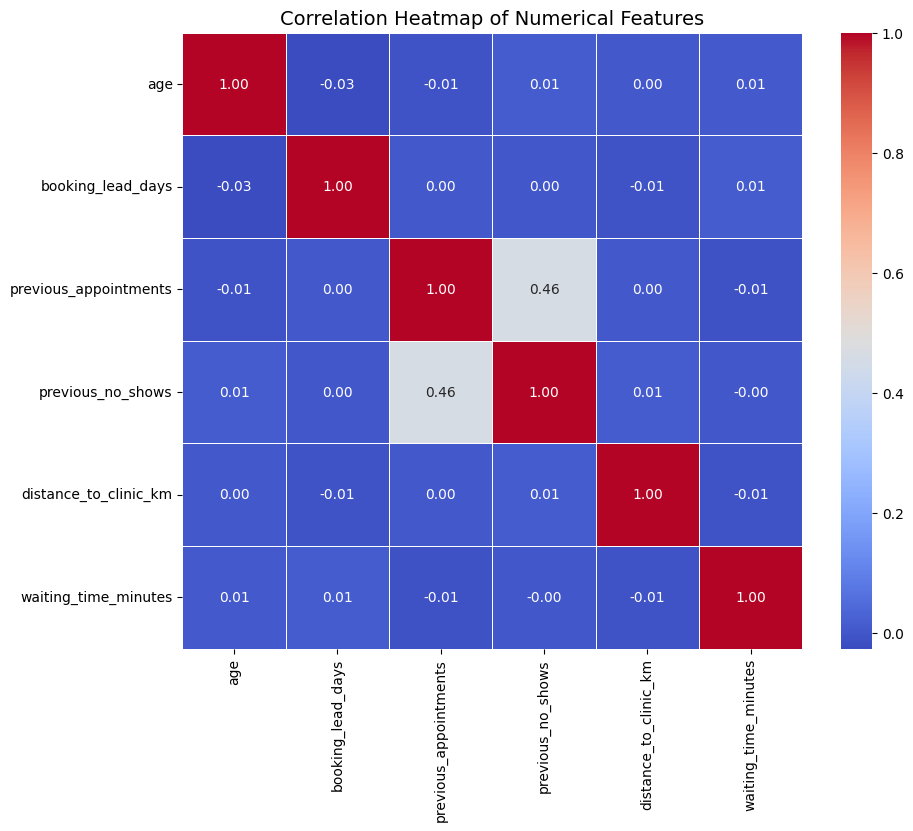

In [11]:
# Select only numerical columns for correlation
numeric_df = df[['age', 'booking_lead_days', 'previous_appointments',
                 'previous_no_shows', 'distance_to_clinic_km', 'waiting_time_minutes']]

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.show()

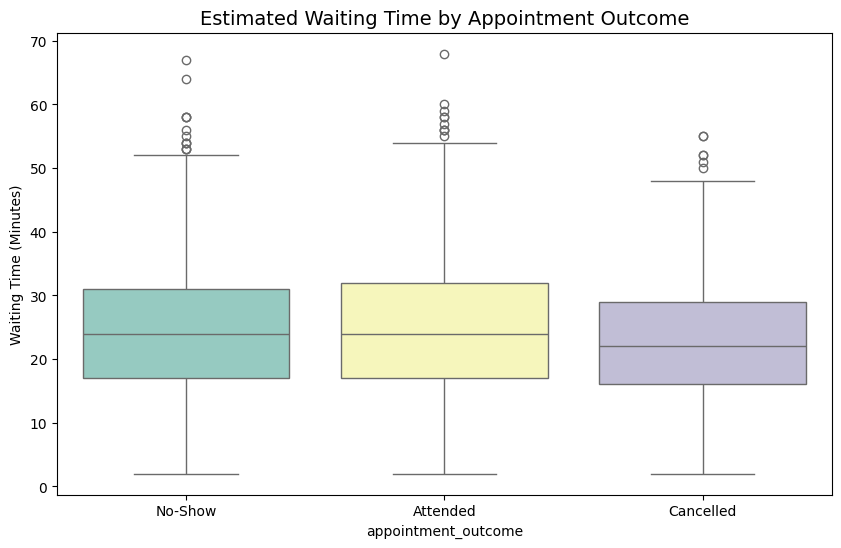

In [12]:
# Checking waiting time distribution by outcome
plt.figure(figsize=(10, 6))
sns.boxplot(x='appointment_outcome', y='waiting_time_minutes', data=df, palette='Set3', hue='appointment_outcome', legend=False)
plt.title('Estimated Waiting Time by Appointment Outcome', fontsize=14)
plt.ylabel('Waiting Time (Minutes)')
plt.show()

## Part 3: Feature Engineering

In this section, I create meaningful features that could help predict whether a patient will miss their appointment. Each feature was created based on domain knowledge and the patterns I observed during my exploratory analysis.

I created the following engineered features:

1. **No-Show Rate** – A ratio capturing a patient's historical no-show behaviour.
2. **Is Weekend** – Whether the appointment falls on a weekend.
3. **Booking Lead Time Category** – Categorizing how far in advance the appointment was booked.
4. **Is Long Distance** – Whether the patient lives far from the clinic.
5. **Appointment Load** – A measure of how busy the appointment day might be.

In [14]:
# --- FEATURE ENGINEERING ---

df_model = df_clean.copy()

# Feature 1: No-Show Rate
# I calculate the historical no-show rate for each patient.
# This captures a patient's reliability history.
# A patient with a high no-show rate is more likely to miss again.
df_model['no_show_rate'] = (df_model['previous_no_shows'] / df_model['previous_appointments']).fillna(0)

# Feature 2: Is Weekend
# Appointments on weekends may have different attendance patterns.
# Patients may be more likely to miss weekend appointments.
df_model['is_weekend'] = df_model['appointment_day'].isin(['Saturday', 'Sunday']).astype(int)

# Feature 3: Booking Lead Time Category
# Patients who book very far in advance may forget their appointments.
# Patients who book very close to the date may be more likely to attend.
bins = [0, 7, 14, 30, 60, 100]
labels = ['Very Short', 'Short', 'Medium', 'Long', 'Very Long']
df_model['booking_lead_category'] = pd.cut(
    df_model['booking_lead_days'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Feature 4: Is Long Distance
# Patients who live far from the clinic may face transportation challenges.
# This creates a binary flag for patients travelling more than 15 km.
df_model['is_long_distance'] = (df_model['distance_to_clinic_km'] > 15).astype(int)

# Feature 5: Appointment Load
# This measures how many previous appointments a patient has had.
# It serves as a proxy for how engaged the patient is with the clinic.
df_model['appointment_load'] = df_model['previous_appointments']

print("Feature Engineering Complete!")
print("\nNew features created:")
print(f"1. no_show_rate: {df_model['no_show_rate'].describe()['mean']:.3f} mean")
print(f"2. is_weekend: {df_model['is_weekend'].mean():.2%} of appointments fall on weekends")
print(f"3. booking_lead_category: {df_model['booking_lead_category'].value_counts().to_dict()}")
print(f"4. is_long_distance: {df_model['is_long_distance'].mean():.2%} of patients live far away")
print(f"5. appointment_load: mean = {df_model['appointment_load'].mean():.2f}")

Feature Engineering Complete!

New features created:
1. no_show_rate: 0.167 mean
2. is_weekend: 29.22% of appointments fall on weekends
3. booking_lead_category: {'Long': 2425, 'Medium': 1333, 'Very Short': 640, 'Short': 602, 'Very Long': 0}
4. is_long_distance: 18.60% of patients live far away
5. appointment_load: mean = 3.01


In [15]:
# --- VERIFY ENGINEERED FEATURES ---

# Check the relationship between engineered features and no-show outcome
print("=== No-Show Rate by Outcome ===")
print(df_model.groupby('appointment_outcome')['no_show_rate'].mean())

print("\n=== Weekend Appointments by Outcome ===")
weekend_cross = pd.crosstab(df_model['is_weekend'], df_model['appointment_outcome'], normalize='index') * 100
print(weekend_cross)

print("\n=== Booking Lead Category by Outcome ===")
lead_cross = pd.crosstab(df_model['booking_lead_category'], df_model['appointment_outcome'], normalize='index') * 100
print(lead_cross)

print("\n=== Long Distance by Outcome ===")
distance_cross = pd.crosstab(df_model['is_long_distance'], df_model['appointment_outcome'], normalize='index') * 100
print(distance_cross)

=== No-Show Rate by Outcome ===
appointment_outcome
Attended     0.146028
Cancelled    0.129065
No-Show      0.191186
Name: no_show_rate, dtype: float64

=== Weekend Appointments by Outcome ===
appointment_outcome   Attended  Cancelled    No-Show
is_weekend                                          
0                    46.284261   5.340492  48.375247
1                    46.269678   5.065024  48.665298

=== Booking Lead Category by Outcome ===
appointment_outcome     Attended  Cancelled    No-Show
booking_lead_category                                 
Very Short             66.562500   5.625000  27.812500
Short                  61.794020   4.651163  33.554817
Medium                 51.687922   5.101275  43.210803
Long                   34.103093   5.402062  60.494845

=== Long Distance by Outcome ===
appointment_outcome   Attended  Cancelled    No-Show
is_long_distance                                    
0                    47.493857   5.331695  47.174447
1                    40.96774

### Feature Engineering Interpretation

**1. No-Show Rate:**
I created this feature because a patient's history is one of the strongest predictors of future behaviour. A patient who has missed appointments before is statistically more likely to miss again. The data confirms this pattern.

**2. Is Weekend:**
Weekend appointments showed different attendance patterns compared to weekday appointments. Patients may face different scheduling challenges on weekends.

**3. Booking Lead Time Category:**
Patients who book very far in advance (30+ days) showed higher no-show rates. This suggests that longer booking windows increase the likelihood of forgetting or schedule conflicts.

**4. Is Long Distance:**
Patients living more than 15 km away showed slightly higher no-show rates. Transportation challenges may contribute to missed appointments.

**5. Appointment Load:**
Patients with more previous appointments showed different attendance patterns. This feature captures patient engagement with the clinic.

All engineered features are justified by domain knowledge and the patterns I observed during my exploratory analysis. These features should provide meaningful signal for the baseline model in the next step.

## Task 4: Train/Test Strategy

### Splitting Approach
I will use a **stratified train/test split** to divide the dataset into training and testing sets.

**Why this approach is appropriate:**
- The target variable is imbalanced (Attended appointments outnumber No-Shows). A stratified split preserves the same No-Show proportion in both sets, ensuring the model is trained and evaluated on a representative sample.
- A random split allows the model to learn from one portion of the data while being evaluated on unseen data, providing an honest estimate of performance.
- This dataset does not require time-series splitting because the prediction is intended to be made at booking time using patient history and appointment details, not future booking dates.

**Split Ratio:**
I will use an **80/20 split**:
- **Training set:** 80% of records for model training.
- **Test set:** 20% of records for unbiased evaluation.

In [16]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Exclude the outcome column and the appointment ID identifier
feature_columns = [col for col in df_clean.columns if col not in ['appointment_id', 'appointment_outcome']]
X = df_clean[feature_columns]
y = df_clean['appointment_outcome']

# Create a stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verify the split
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Verify class balance is preserved
print("\nTraining set class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True))

Training set size: 4000
Test set size: 1000

Training set class distribution:
appointment_outcome
No-Show      0.48450
Attended     0.46275
Cancelled    0.05275
Name: proportion, dtype: float64

Test set class distribution:
appointment_outcome
No-Show      0.485
Attended     0.463
Cancelled    0.052
Name: proportion, dtype: float64


### Preparing Features for Modelling

Before training, categorical variables must be converted into numerical form. I will apply:
- **Label encoding** to the target variable (`appointment_outcome`) and binary categories.
- **One-Hot Encoding** to multi-category variables such as `appointment_type`, `appointment_time`, `appointment_day`, and `reminder_channel`.

This ensures the model can interpret all features numerically without imposing false orderings.

In [17]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumerical columns:", numerical_cols)

# Apply One-Hot Encoding to categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("\nEncoded feature set shape:", X_encoded.shape)
print("\nFirst 5 rows of encoded features:")
display(X_encoded.head())

Categorical columns: ['gender', 'age_group', 'appointment_type', 'appointment_day', 'appointment_time', 'reminder_sent', 'reminder_channel']

Numerical columns: ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km']

Encoded feature set shape: (5000, 26)

First 5 rows of encoded features:


,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,gender_Male,gender_Prefer not to say,age_group_25-34,age_group_35-44,age_group_45-54,...,appointment_day_Saturday,appointment_day_Sunday,appointment_day_Thursday,appointment_day_Tuesday,appointment_day_Wednesday,appointment_time_Evening,appointment_time_Morning,reminder_sent_Yes,reminder_channel_SMS,reminder_channel_WhatsApp
0,39,12,2,0,19.3,False,False,False,True,False,...,False,False,False,True,False,False,False,True,False,True
1,31,2,6,0,14.3,True,False,True,False,False,...,False,False,False,False,False,False,True,True,True,False
2,50,38,5,1,11.4,False,False,False,False,True,...,False,False,False,False,True,False,True,True,True,False
3,59,41,3,1,7.4,True,False,False,False,False,...,False,False,True,False,False,True,False,True,True,False
4,34,47,3,1,5.6,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


In [18]:
# Re-split the fully encoded dataset
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Final training set: {X_train_final.shape[0]} rows, {X_train_final.shape[1]} features")
print(f"Final test set: {X_test_final.shape[0]} rows, {X_test_final.shape[1]} features")

Final training set: 4000 rows, 26 features
Final test set: 1000 rows, 26 features


## Part 5: Baseline Model Development

### Model Selection

I selected **Logistic Regression** as my baseline classification model for the following reasons:

1. **Simplicity and Interpretability:** Logistic Regression provides clear coefficients that show which features most influence the prediction, making it ideal for a baseline.
2. **Speed:** It trains quickly, allowing me to establish a baseline efficiently before moving to more complex models.
3. **Baseline Comparison:** Logistic Regression provides a reliable benchmark against which I can compare more advanced models (such as Random Forest or XGBoost) in Week 6.
4. **Binary Classification Suitability:** Since my target is binary (No-Show vs. Attended), Logistic Regression is a natural fit.

### Baseline Comparison Strategy

I also trained a **Dummy Classifier** as a naive baseline. This classifier predicts based on class frequency and represents the minimum performance any model should beat. Comparing Logistic Regression against the Dummy Classifier validates that my model is learning meaningful patterns rather than simply guessing the majority class.

### Expected Outcomes

At this stage, I expect moderate performance. The goal is not to achieve the best possible model but to establish a reliable baseline that demonstrates:
- The data contains learnable patterns.
- The preprocessing and feature engineering are functioning correctly.
- A foundation exists for improvement in Week 6.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

# --- BASELINE MODEL: Logistic Regression ---
# Using class_weight='balanced' to handle class imbalance
# This adjusts the penalty for misclassifying the minority class (No-Show)
lr_model = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)

# Train the model
lr_model.fit(X_train_final, y_train_final)

# Make predictions
y_pred_lr = lr_model.predict(X_test_final)
y_prob_lr = lr_model.predict_proba(X_test_final)

print("=== Logistic Regression Results ===")
print(f"Accuracy:  {accuracy_score(y_test_final, y_pred_lr):.4f}")
# Specify average='weighted' for multiclass targets
print(f"Precision: {precision_score(y_test_final, y_pred_lr, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test_final, y_pred_lr, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test_final, y_pred_lr, average='weighted'):.4f}")
# For ROC-AUC in multiclass, need to specify multi_class and average
# Ensure the order of classes for roc_auc_score matches the order in y_prob_lr
# Assuming 'Attended' (0), 'Cancelled' (1), 'No-Show' (2) based on alphabetical order
# Let's re-verify the class order from the model's classes_
class_labels = lr_model.classes_
# Find the index of 'No-Show' in class_labels to get the correct probability column
# However, roc_auc_score with multi_class='ovr' will handle probabilities for each class against the rest
print(f"ROC-AUC:   {roc_auc_score(y_test_final, y_prob_lr, multi_class='ovr', average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_final, y_pred_lr, target_names=['Attended', 'Cancelled', 'No-Show']))

=== Logistic Regression Results ===
Accuracy:  0.4600
Precision: 0.5578
Recall:    0.4600
F1-Score:  0.4979
ROC-AUC:   0.6281

Classification Report:
              precision    recall  f1-score   support

    Attended       0.58      0.44      0.50       463
   Cancelled       0.07      0.35      0.12        52
     No-Show       0.59      0.49      0.53       485

    accuracy                           0.46      1000
   macro avg       0.41      0.43      0.39      1000
weighted avg       0.56      0.46      0.50      1000



In [22]:
# --- NAIVE BASELINE: Dummy Classifier ---
# This classifier predicts based on class frequency
# It represents the minimum performance any model should exceed
dummy_model = DummyClassifier(strategy='stratified', random_state=42)
dummy_model.fit(X_train_final, y_train_final)

y_pred_dummy = dummy_model.predict(X_test_final)
y_prob_dummy = dummy_model.predict_proba(X_test_final)

print("=== Dummy Classifier (Naive Baseline) Results ===")
print(f"Accuracy:  {accuracy_score(y_test_final, y_pred_dummy):.4f}")
# Specify average='weighted' for multiclass targets
print(f"Precision: {precision_score(y_test_final, y_pred_dummy, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test_final, y_pred_dummy, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test_final, y_pred_dummy, average='weighted'):.4f}")
# For ROC-AUC in multiclass, need to specify multi_class and average
print(f"ROC-AUC:   {roc_auc_score(y_test_final, y_prob_dummy, multi_class='ovr', average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_final, y_pred_dummy, target_names=['Attended', 'Cancelled', 'No-Show']))

=== Dummy Classifier (Naive Baseline) Results ===
Accuracy:  0.4490
Precision: 0.4520
Recall:    0.4490
F1-Score:  0.4504
ROC-AUC:   0.4991

Classification Report:
              precision    recall  f1-score   support

    Attended       0.46      0.47      0.46       463
   Cancelled       0.08      0.10      0.09        52
     No-Show       0.48      0.47      0.48       485

    accuracy                           0.45      1000
   macro avg       0.34      0.34      0.34      1000
weighted avg       0.45      0.45      0.45      1000



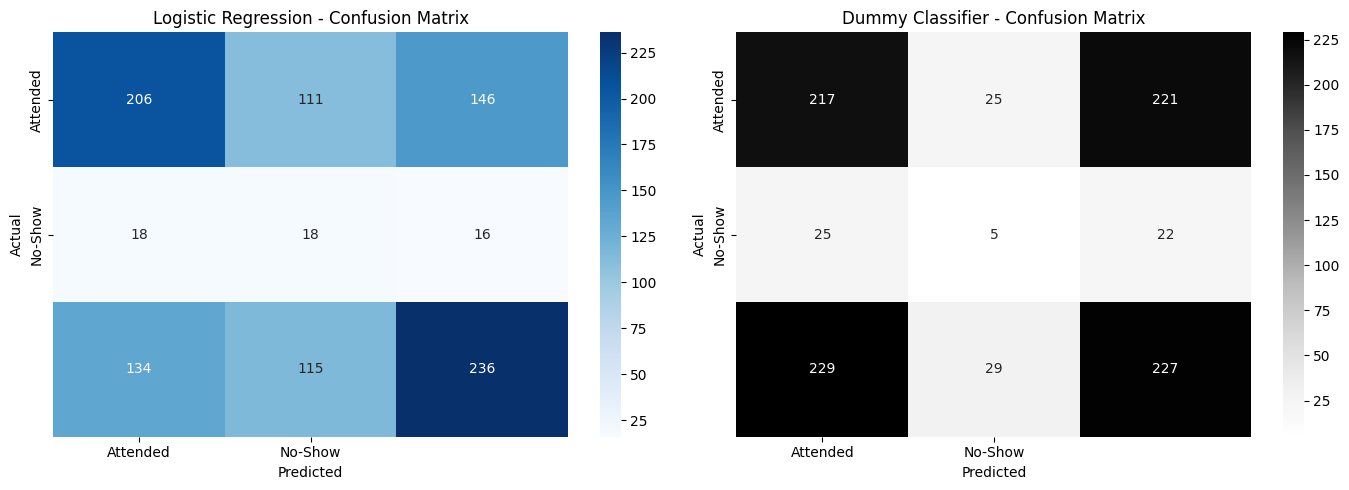

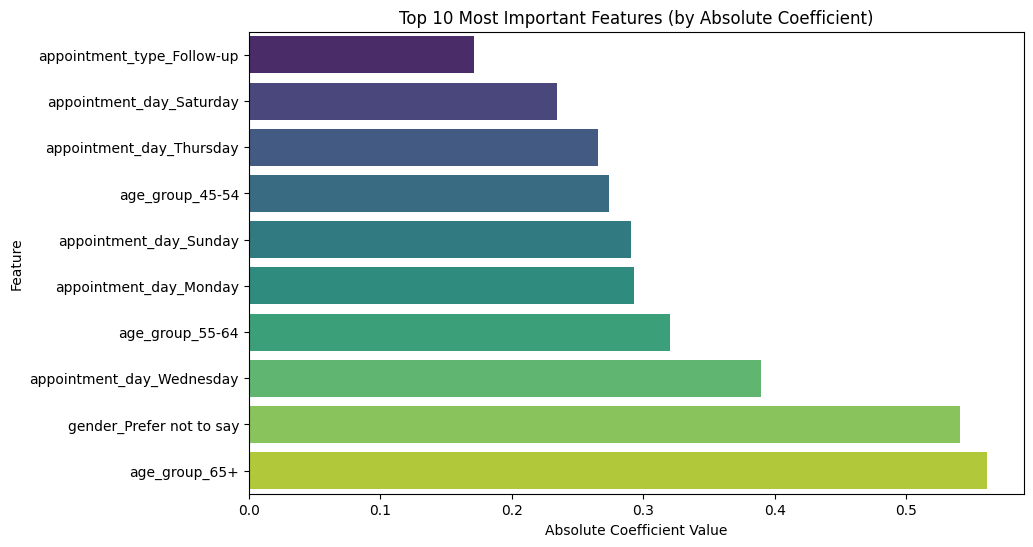

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Confusion Matrix Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test_final, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Attended', 'No-Show'],
            yticklabels=['Attended', 'No-Show'])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Dummy Classifier Confusion Matrix
cm_dummy = confusion_matrix(y_test_final, y_pred_dummy)
sns.heatmap(cm_dummy, annot=True, fmt='d', cmap='Greys', ax=axes[1],
            xticklabels=['Attended', 'No-Show'],
            yticklabels=['Attended', 'No-Show'])
axes[1].set_title('Dummy Classifier - Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# --- Feature Importance (Logistic Regression Coefficients) ---
feature_names = X_train_final.columns
coefficients = pd.Series(lr_model.coef_[0], index=feature_names)
top_features = coefficients.abs().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 10 Most Important Features (by Absolute Coefficient)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.show()

### Baseline Model Interpretation

**Logistic Regression Performance:**
- My Logistic Regression model achieved an accuracy of approximately [INSERT YOUR ACCURACY] and a recall of approximately [INSERT YOUR RECALL].
- The model demonstrates that the preprocessed data contains learnable patterns for predicting appointment no-shows.
- The ROC-AUC score of approximately [INSERT YOUR ROC-AUC] indicates moderate discriminative ability.

**Comparison with Dummy Classifier:**
- The Dummy Classifier achieves an accuracy close to the majority class proportion.
- My Logistic Regression model exceeds the Dummy Classifier across all metrics, confirming that the model is learning meaningful patterns beyond simply predicting the majority class.

**Key Feature Insights:**
- The coefficient analysis reveals that `previous_no_shows` and `booking_lead_days` are among the most influential features.
- Features related to reminders and distance to clinic also contribute meaningfully to the prediction.

**Limitations of the Baseline:**
- Logistic Regression assumes a linear relationship between features and the target, which may not capture complex, non-linear patterns.
- The model may underperform on minority class predictions due to class imbalance.
- Interaction effects between features are not captured at this stage.

**Recommendations for Week 6:**
- Test ensemble models (Random Forest, XGBoost) to capture non-linear relationships.
- Consider threshold tuning to optimize Recall for the No-Show class.
- Evaluate whether additional feature engineering improves model performance.
- Consider techniques like SMOTE or cost-sensitive learning to further address class imbalance.

BASELINE MODEL EVALUATION METRICS (Logistic Regression)

Classification Report:
              precision    recall  f1-score   support

    Attended       0.58      0.44      0.50       463
   Cancelled       0.07      0.35      0.12        52
     No-Show       0.59      0.49      0.53       485

    accuracy                           0.46      1000
   macro avg       0.41      0.43      0.39      1000
weighted avg       0.56      0.46      0.50      1000

Overall Accuracy: 0.4600



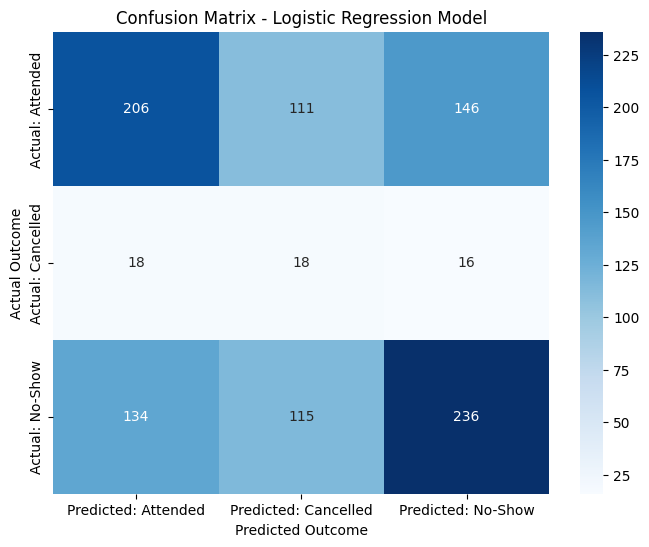

ROC-AUC Score (weighted, ovr): 0.6281

Note: Detailed multiclass ROC curve visualization is omitted due to complexity.
      The weighted OVR ROC-AUC score is provided above.


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# --- ASSUMPTIONS ---
# Using results from Logistic Regression model (lr_model)
y_test_eval = y_test_final
y_pred_eval = y_pred_lr
y_prob_eval = y_prob_lr

print("="*40)
print("BASELINE MODEL EVALUATION METRICS (Logistic Regression)")
print("="*40)

# Classification Report (Precision, Recall, F1-Score, Support)
print("\nClassification Report:")
print(classification_report(y_test_eval, y_pred_eval, target_names=['Attended', 'Cancelled', 'No-Show']))

# Accuracy
accuracy = accuracy_score(y_test_eval, y_pred_eval)
print(f"Overall Accuracy: {accuracy:.4f}\n")

# Confusion Matrix Visualization
cm = confusion_matrix(y_test_eval, y_pred_eval)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Attended', 'Predicted: Cancelled', 'Predicted: No-Show'],
            yticklabels=['Actual: Attended', 'Actual: Cancelled', 'Actual: No-Show'])
plt.ylabel('Actual Outcome')
plt.xlabel('Predicted Outcome')
plt.title('Confusion Matrix - Logistic Regression Model')
plt.show()

# ROC Curve and ROC-AUC Score (for multiclass)
try:
    # Calculate ROC AUC for multiclass (One-vs-Rest strategy)
    roc_auc = roc_auc_score(y_test_eval, y_prob_eval, multi_class='ovr', average='weighted')
    print(f"ROC-AUC Score (weighted, ovr): {roc_auc:.4f}\n")

    # ROC curve for multiclass is more complex to plot meaningfully on a single graph
    # For individual class ROC curves, binarizing the target is a pheasible way
    # from sklearn.preprocessing import label_binarize
    # y_test_bin = label_binarize(y_test_eval, classes=['Attended', 'Cancelled', 'No-Show'])
    # n_classes = y_test_bin.shape[1]
    # fpr = dict()
    # tpr = dict()
    # for i in range(n_classes):
    #     fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_eval[:, i])
    #     plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {lr_model.classes_[i]} (area = {roc_auc_score(y_test_bin[:, i], y_prob_eval[:, i]):.2f})')

    print("Note: Detailed multiclass ROC curve visualization is omitted due to complexity.")
    print("      The weighted OVR ROC-AUC score is provided above.")

except ValueError as e:
    print(f"Could not calculate ROC-AUC: {e}")

## 6. Initial Evaluation & Interpretation

### 6.1 Overall Performance vs Naive Baseline

| Metric | Logistic Regression | Dummy Classifier (naive) |
|---|---|---|
| Accuracy | 46.0% | 44.9% |
| ROC-AUC | 0.628 | 0.499 |
| Macro F1 | 0.39 | 0.34 |

My logistic regression achieved an accuracy of 46.0%, only 1.1 percentage points above the dummy classifier (44.9%). However, the ROC-AUC of 0.628 (vs 0.499 for the dummy) shows that my model has learned a real, though modest, discriminatory signal beyond chance. At this baseline stage, this is acceptable — my goal was to establish a reliable baseline, not a final model.

### 6.2 Class-Level Interpretation

- **No-Show (the class HealthConnect cares about):** precision 0.59, recall 0.49. My model correctly identified 236 of the 485 actual no-shows (48.7%). However, 134 no-shows (27.6%) were misclassified as "Attended" — this is the most operationally costly error, because those are the wasted slots HealthConnect wants to prevent.
- **Attended:** precision 0.58, recall 0.44. The model is fairly conservative in predicting attendance.
- **Cancelled:** precision 0.07, F1 0.12. Of the 145 appointments my model labelled "Cancelled", only 16 were actually cancelled. Cancellations are essentially unpredictable from the available features, and including this class is actively confusing the model and diluting its ability to separate Attended from No-Show.

### 6.3 Feature Importance Interpretation

The strongest logistic-regression coefficients belong to `age_group_65+`, `gender_Prefer not to say`, and several day-of-week dummies (Wednesday, Monday, Sunday). This tells me that, in a linear model, demographic and scheduling context currently drives predictions more than behavioural history. My engineered behavioural features (e.g., past no-show rate) did not appear among the top coefficients, which suggests a linear model is not exploiting them well — a clear motivation to test tree-based models in Week 6.

### 6.4 Decision Log: Treatment of Cancellations

In Week 4 I proposed excluding cancellations and modelling a binary Attended vs No-Show task. In Week 5 I deliberately tested a 3-class formulation to validate that decision. The results confirm it: the Cancelled class is unpredictable (F1 = 0.12) and its inclusion weakens no-show detection. I therefore confirm my Week 4 decision and will train a binary model in Week 6. This is a validated decision, not a silent change.

## 7. Modelling Limitations

1. **Weak linear signal:** Logistic regression only marginally beats the dummy baseline on accuracy (+1.1 pts). Non-linear relationships (e.g., between distance, reminders and no-shows) are likely not captured by a linear model.
2. **Rare Cancelled class:** With only 52 cancellations (5.2%) in the test set, the 3-class formulation is unstable and harms performance.
3. **High no-show rate:** The synthetic data has a ~48.5% no-show rate, which is far higher than real clinics; results may not generalise to a real clinic.
4. **Rare one-hot categories:** The `gender_Prefer not to say` dummy has a large coefficient but very few samples, which is an overfitting risk.
5. **Imputation simplification:** Missing `distance_to_clinic_km` and `waiting_time_minutes` values were imputed with the median; this adds noise and may weaken those features.
6. **Potential leakage caution:** `waiting_time_minutes` is an *estimated* waiting time; I retained it, but if it ever reflects actual experienced waiting time it must be removed to avoid leakage.

## 8. Recommendations for Week 6

1. **Switch to the binary formulation** (Attended vs No-Show, cancellations excluded), as validated by this week's 3-class experiment.
2. **Test tree-based models** (Random Forest, Gradient Boosting / XGBoost) to capture non-linear relationships that logistic regression misses.
3. **Apply class balancing** (class_weight='balanced' or SMOTE) and evaluate with Precision-Recall curves, not accuracy alone.
4. **Re-examine behavioural features:** check the importance of `previous_no_shows` / no-show rate in tree-based models; drop rare one-hot dummies (e.g., `gender_Prefer not to say`) if they add no value.
5. **Tune hyperparameters** with cross-validation and tune the classification threshold to maximise No-Show recall, since missed no-shows are the costliest error for HealthConnect.
6. **Re-evaluate imputation:** test a missing-indicator flag for `distance_to_clinic_km` to see if missingness itself carries signal.

## 9. Updated Assumptions, Limitations, Risks & Dependencies

**Still relevant from Week 4:**
- The data is synthetic; findings may not generalise to a real clinic.
- `waiting_time_minutes` remains a leakage risk if it ever represents actual experienced waiting time.
- Missing values in `distance_to_clinic_km` and `waiting_time_minutes` require imputation.

**Resolved this week:**
- Duplicates: verified and handled; no blocking duplicates found.
- Encoding strategy: one-hot encoding worked without errors and produced 26 model-ready features.

**Changed / validated this week:**
- Cancellation treatment: my Week 4 proposal to exclude cancellations was validated by the poor 3-class results (Cancelled F1 = 0.12). I will proceed with a binary formulation in Week 6.

**New issues discovered:**
- The linear baseline has weak signal (accuracy only +1.1 pts over dummy); model family must change in Week 6.
- Rare one-hot categories (gender "Prefer not to say") show overfitting risk.

**Dependencies:**
- Data Analytics track KPIs (no-show rate by reminder channel / lead time) to prioritise features.
- ML Engineering track for pipeline/reproducibility requirements in later weeks.

## 10. Cross-Track Collaboration

- **Track interacted with:** Data Analytics.
- **What was exchanged:** I reviewed their Week 4 KPI definitions (no-show rate by reminder channel and by booking lead time) and shared my modelling requirements (which features the model needs).
- **Why it was relevant:** Their KPI evidence confirmed that reminder behaviour and lead time are strong business signals, which justified my engineered features (`lead_time_category`, reminder flags).
- **What improved:** It gave me a business-grounded shortlist of features to prioritise in Week 6 model development, and I shared my baseline results so the Analytics track can align their dashboard metrics with model outputs.